# Analysze NMR data

Analysis of the NMR data we got including: 
1. NICS data - for pyrroles
    - Are the NICS values are symmetrical for each pyrrole?
    - ~~What is the difference between pyrroles?~~
    - ~~Do the NICS correlate with the HOMA (of each pyrrole)?~~
2. Atomic chemical shift data
    - ~~What are the typical values for the metal center?~~
    - Do the NICS values correlate wity pyrrole's hydrogen shifts?

In [1]:
import sys; sys.path.append("..")
import numpy as np
# connect to database
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
engine = create_engine("sqlite:///{}".format("../main.db"))
session = sessionmaker(bind=engine)()
from src import utils
import matplotlib as mpl
import matplotlib.pyplot as plt
c = "#F2F2F2"
mpl.rcParams["figure.facecolor"] = c
mpl.rcParams["axes.facecolor"] = c
mpl.rcParams["savefig.facecolor"] = c
plt.rcParams['font.size'] = 16
utils.define_pallet()

## NICS analysis

In [2]:
# fetch all data
from src.sqlmodels import StructureProperty
import pandas as pd
# fetch all rows matching the filter and convert to DataFrame
rows = session.query(StructureProperty).filter(StructureProperty.source.like("%nics%")).all()
raw = pd.DataFrame([r.__dict__ for r in rows]).drop('_sa_instance_state', axis=1)
# fabulize dataframe
raw["pyrrole"] = [int(x.split("/")[0][-1]) for x in raw["property"]]
raw["z"] = [float(x.split("/")[1][1:]) for x in raw["property"]]
raw["type"] = [x.split("/")[-1] for x in raw["property"]]
raw["value"] = - raw["value"] # to obey the convention of NICS notation
raw = raw[["structure", "pyrrole", "z", "type", "value"]]
raw = raw[raw["type"] != "anisotropic"]

In [3]:
len(raw["structure"].unique())

306

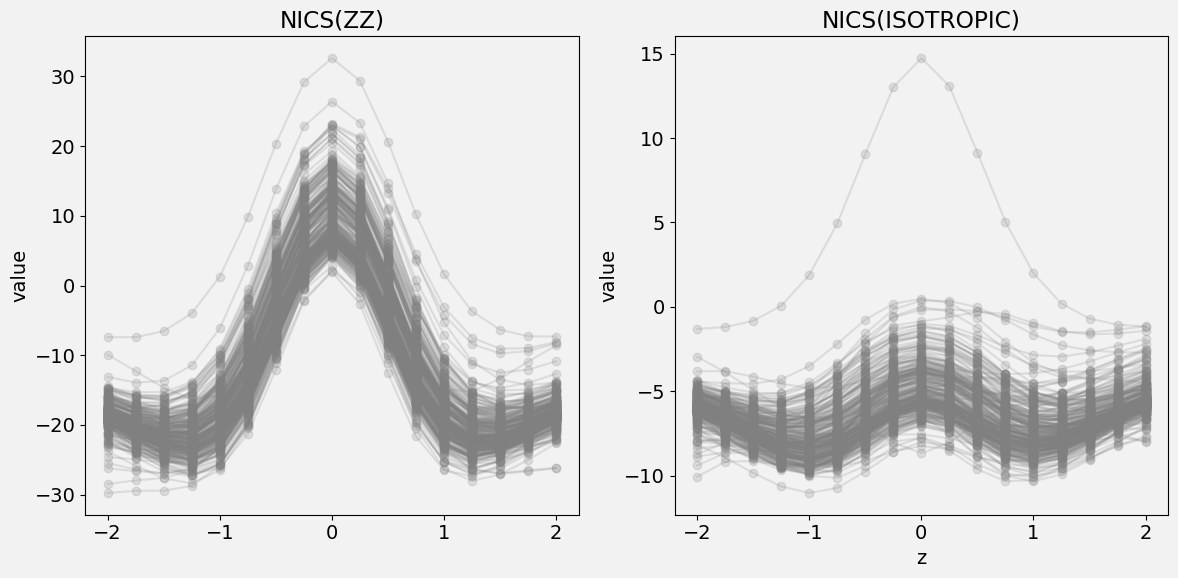

In [4]:
# firt plot the different values of the NICS scan - by the different types
import matplotlib.pyplot as plt

types = raw["type"].unique()
n_types = len(types)

fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 6), sharex=True)

if n_types == 1:
    axes = [axes]

# average values of different pyrroles for each z and structure
df_avg = raw.groupby(['structure', 'z', 'type'], as_index=False)['value'].mean()

for ax, t in zip(axes, types):
    subset = df_avg[df_avg["type"] == t]
    for structure, group in subset.groupby("structure"):
        group = group.sort_values("z")
        ax.plot(group["z"], group["value"], marker='o', label=structure, color="gray", alpha=0.2)
    ax.set_title(f'NICS({t.upper()})')
    ax.set_ylabel('value')
    # ax.legend(title='structure', bbox_to_anchor=(1.05, 1), loc='upper left')

axes[-1].set_xlabel('z')
plt.tight_layout()

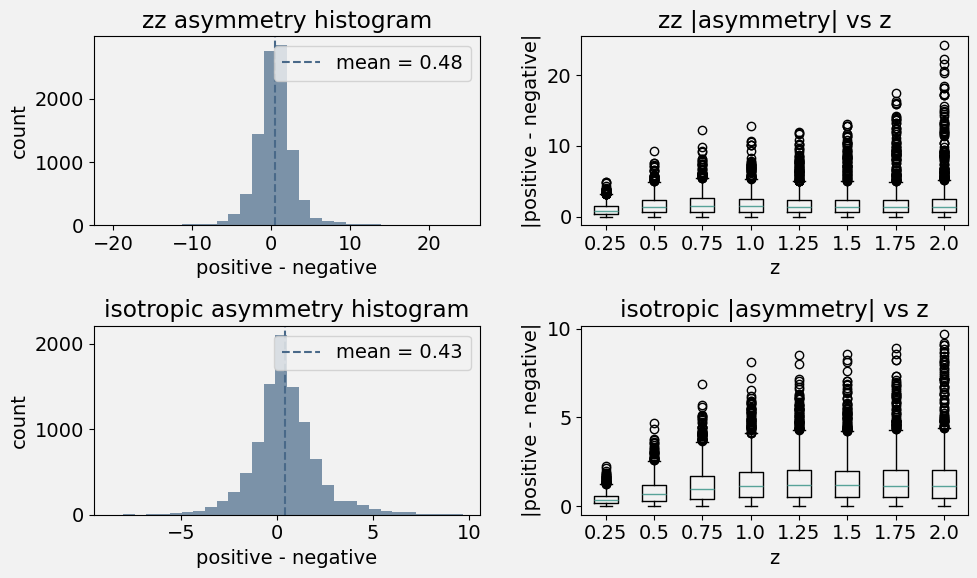

In [5]:
# analyze assymetry of the NICS signals

# For each structure, pyrrole, type, and |z|, calculate value(z) - value(-z)
asymmetry = []
for (structure, pyrrole, t), group in raw.groupby(["structure", "pyrrole", "type"]):
    # Only consider z values that have both +z and -z
    z_vals = np.intersect1d(np.abs(group["z"]), np.abs(group["z"]))
    for z in np.unique(np.abs(group["z"])):
        if z == 0:
            continue  # skip z=0
        pos = group[group["z"] == z]
        neg = group[group["z"] == -z]
        if not pos.empty and not neg.empty:
            diff = pos["value"].values[0] - neg["value"].values[0]
            asymmetry.append({
                "structure": structure,
                "pyrrole": pyrrole,
                "type": t,
                "z": z,
                "asymmetry": diff
            })

asym_df = pd.DataFrame(asymmetry)
nics_types = ["zz", "isotropic"]
fig, axs = plt.subplots(nrows=len(nics_types), ncols=2, figsize=(10, 3 * len(nics_types)))
for i, t in enumerate(nics_types):
    data = asym_df[asym_df["type"] == t]
    axs[i, 0].hist(data["asymmetry"], bins=30, alpha=0.7)
    mean_asym = data["asymmetry"].mean()
    axs[i, 0].axvline(mean_asym, linestyle='--', label=f"mean = {mean_asym:.2f}")
    axs[i, 0].legend()
    axs[i, 0].set_title(f"{t} asymmetry histogram")
    axs[i, 0].set_xlabel("positive - negative")
    axs[i, 0].set_ylabel("count")
    # Create a boxplot of |asymmetry| for each unique z value
    z_unique = np.sort(data["z"].unique())
    xs = range(len(z_unique))
    box_data = [np.abs(data[data["z"] == z_val]["asymmetry"]) for z_val in z_unique]
    axs[i, 1].boxplot(box_data, positions=xs)
    axs[i, 1].set_xticklabels(z_unique)
    axs[i, 1].set_title(f"{t} |asymmetry| vs z")
    axs[i, 1].set_xlabel("z")
    axs[i, 1].set_ylabel("|positive - negative|")
plt.tight_layout()


In [5]:
# make a summary per structure and pyrrole
# Pivot table: minimum "value" for each (structure, pyrrole) (rows) and type (columns)
df = raw.pivot_table(index=["structure", "pyrrole"], columns="type", values="value", aggfunc="min")
df = df.sort_index()

# # Add NICS(1) columns: value at z=1 for each type, grouped by structure and pyrrole
# for t in raw["type"].unique():
#     nics1 = raw[(raw["z"] == 1) & (raw["type"] == t)][["structure", "pyrrole", "value"]].groupby(["structure", "pyrrole"]).mean().sort_index()
#     nicsm1 = raw[(raw["z"] == -1) & (raw["type"] == t)][["structure", "pyrrole", "value"]].groupby(["structure", "pyrrole"]).mean().sort_index()
#     nics1_aligned = nics1.reindex(df.index)
#     nicsm1_aligned = nicsm1.reindex(df.index)
#     nics1 = pd.DataFrame({'nics1': nics1_aligned['value'], 'nicsm1': nicsm1_aligned['value']}).min(axis=1)
#     df[f"NICS(1)_{t}"] = nics1.values

len(df) / 4

208.0

In [6]:
# nics_types = raw["type"].unique()
# fig, axs = plt.subplots(ncols=len(nics_types), figsize=(10, 5))
# for ax, t in zip(axs, nics_types):
#     ax.scatter(df[t], df["NICS(1)_" + t])
#     ax.set_xlabel("NICS(MIN)")
#     ax.set_ylabel("NICS(1)")
#     ax.set_title(t)
# plt.tight_layout()

Text(0.01, 0.99, '$r^2$ = 0.527\nMAE = 14.097')

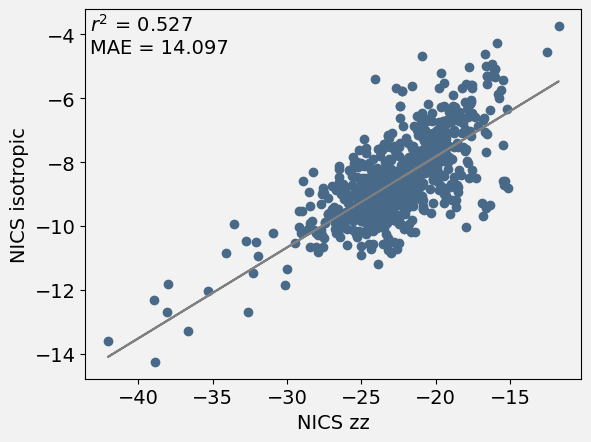

In [37]:
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.linear_model import LinearRegression

plt.scatter(df["zz"], df["isotropic"])
plt.xlabel("NICS zz")
plt.ylabel("NICS isotropic")

# Fit and plot the best-fit line

X = df["zz"].values.reshape(-1, 1)
y = df["isotropic"].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
plt.plot(df["zz"], y_pred, color='gray', label='Best-fit line')

# Calculate Pearson r^2 and MAE
pearson_r = np.corrcoef(df["zz"], df["isotropic"])[0, 1]
r2 = pearson_r ** 2
mae = mean_absolute_error(df["zz"], df["isotropic"])

# Add text to the plot
plt.text(
    0.01, 0.99,
    f"$r^2$ = {r2:.3f}\nMAE = {mae:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

isotropic NICS and NICS zz seem to correlate quite alright. although they do differ significatnly in range and for some compounds... supposingly NICSzz is better for our purpose (isolating local aromaticity) but who knows which has less biases and weirdness

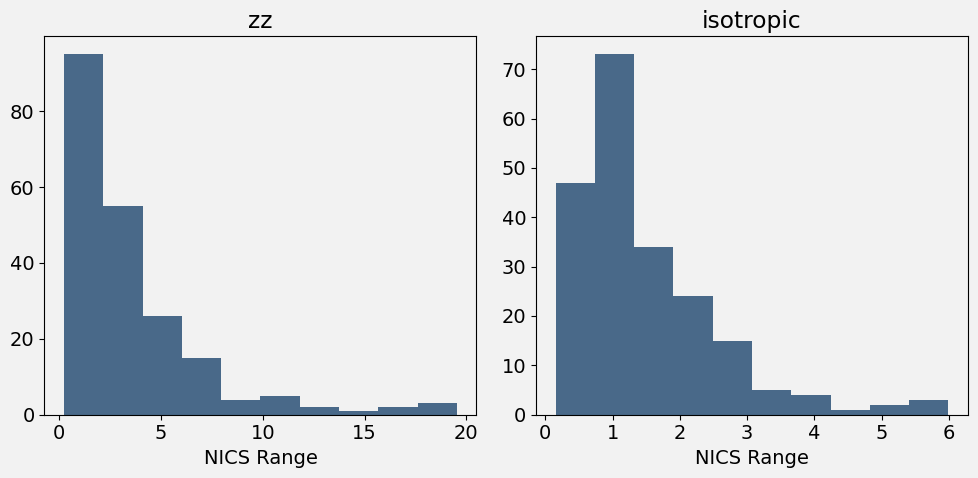

In [38]:
# Reset the index to remove the multi-index and flatten the DataFrame
ajr = df.reset_index().groupby("structure")
ajr = ajr.max() - ajr.min()
nics_types = raw["type"].unique()
fig, axs = plt.subplots(ncols=len(nics_types), figsize=(10, 5))
for ax, t in zip(axs, nics_types):
    ax.hist(ajr[t])
    ax.set_xlabel("NICS Range")
    ax.set_title(t)
plt.tight_layout()

NOTE: the range of values between pyrroles in the same molecule is quite large (up to 15 ppm). these things can stem from benzene rings in the substituents/ligands that contribute to the shielding on some positions. 

In [10]:
q = session.query(StructureProperty.structure, StructureProperty.property, StructureProperty.value).filter(StructureProperty.source == 'homa/dft').filter(StructureProperty.property.like("%pyrrole%")).filter(StructureProperty.property.like("%homa%"))
homa_df = pd.read_sql(q.statement, session.connection())
homa_df["pyrrole"] = [int(s.split()[0][-1]) for s in homa_df["property"]]
homa_df = homa_df.drop(columns=["property"]).set_index(["structure", "pyrrole"])
homa_df = homa_df.rename(columns={"value": "homa"})
df = pd.merge(df, homa_df, how="left", left_index=True, right_index=True)
df

anisotropic  isotropic         zz      homa
structure pyrrole                                             
AKOTUQ    1            -22.579     -9.494 -22.165564  0.694062
          2            -23.551     -8.592 -21.522478  0.746310
          3            -26.239     -9.890 -24.663180  0.658933
          4            -25.568     -9.768 -24.200715  0.661314
APANUC    1            -24.025     -8.790 -23.418503  0.635410
...                        ...        ...        ...       ...
XEPZOI    4            -25.727     -9.362 -25.201306  0.772336
XEPZUO    1            -26.717    -10.280 -27.641104  0.783681
          2            -22.461     -8.540 -23.054510  0.722054
          3            -23.241     -8.858 -23.530348  0.660381
          4            -27.282    -10.368 -27.535682  0.781982

[832 rows x 4 columns]

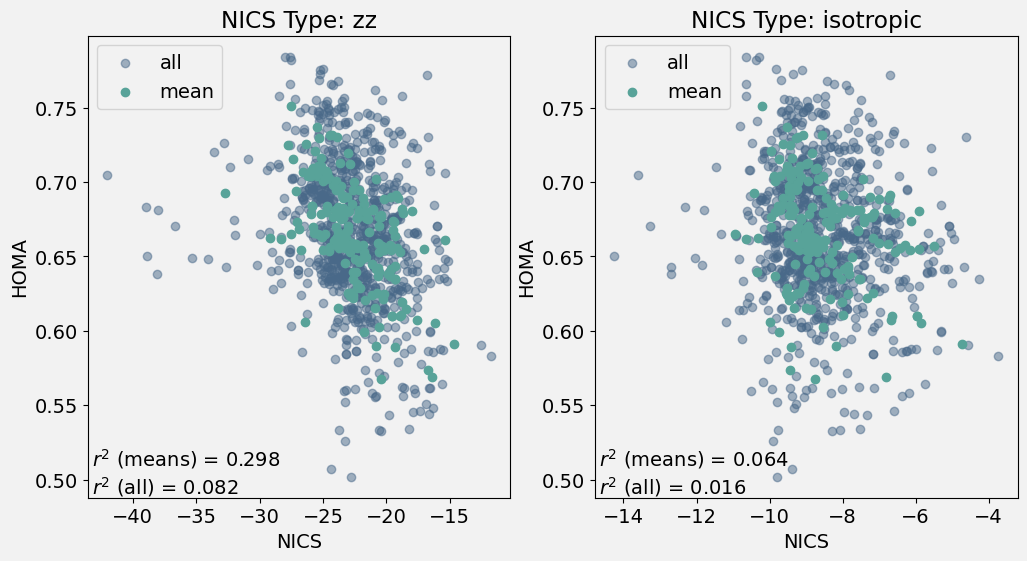

In [40]:
nics_types = ["zz", "isotropic"]
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))
ajr = df.groupby("structure").mean()
for ax, t in zip(axs, nics_types):
    ax.scatter(df[t], df["homa"], label="all", alpha=0.5)
    ax.scatter(ajr[t], ajr["homa"], label="mean")
    # Calculate Pearson r^2
    pearson_r = np.corrcoef(ajr[t], ajr["homa"])[0, 1]
    r2means = pearson_r ** 2
    pearson_r = np.corrcoef(df[t], df["homa"])[0, 1]
    r2all = pearson_r ** 2

    # Add text to the plot
    ax.text(
        0.01, 0.11,
        f"$r^2$ (means) = {r2means:.3f}\n$r^2$ (all) = {r2all:.3f}",
        transform=ax.transAxes,
        verticalalignment='top'
    )

    ax.set_xlabel("NICS")
    ax.set_ylabel("HOMA")
    ax.set_title(f"NICS Type: {t}")
    ax.legend(loc="upper left")

- The NICS and HOMA values do not correlate super well
- for individual pyrroles the correlation is basically random, with slight (expected) negative relation
- when switching to mean pyrrole NICS/HOMA they correlate quite a bit better, with NICSzz being slightly better correlated
- with that said, and as we feared all along, HOMA and NICS do not play well together, and each sufferes from its own unique biases and issues... 

## ATOMIC SHIELDING

In [12]:
import re

q = session.query(StructureProperty.structure, StructureProperty.property, StructureProperty.value).filter(StructureProperty.source.like("%shielding")).filter(~StructureProperty.property.like("%anisotropic"))
raw_shielding = pd.read_sql(q.statement, session.connection())
raw_shielding["atomindex"] = raw_shielding["property"].apply(lambda s: re.findall(r'\d+', s.split()[0])[0])
raw_shielding["symbol"] = raw_shielding["property"].apply(lambda s: re.findall(r'\D+', s.split()[0])[0])
raw_shielding = raw_shielding.drop(columns=["property"])

In [14]:
from src.sqlmodels import StructureSubstituents
q = session.query(StructureSubstituents.structure, StructureSubstituents.atom_indicis).filter(StructureSubstituents.position == "metal")
metal_shielding = pd.read_sql(q.statement, session.connection())
# Ensure atomindex columns are of the same type for join
metal_shielding["atom_indicis"] = metal_shielding["atom_indicis"].astype(int) - 1
raw_shielding["atomindex"] = raw_shielding["atomindex"].astype(int)

# Perform inner join on structure and atomindex/atom_indicis
ajr = pd.merge(
    metal_shielding,
    raw_shielding,
    left_on=["structure", "atom_indicis"],
    right_on=["structure", "atomindex"],
    how="inner"
)
ajr = ajr[["structure", "atom_indicis", "symbol", "value"]]
ajr

,structure,atom_indicis,symbol,value
0,AKOTUQ,0,Ni,-10639.683
1,APANUC,24,Zn,1622.787
2,ARODOC,74,Rh,-3347.300
3,ATEWUT,39,Zn,1666.853
4,ATUSOX,0,Zn,1656.161
...,...,...,...,...
203,WURQEF,49,Ru,-4490.176
204,XAMHIC,51,Zn,1661.308
205,XEDTAE,72,Ru,-4609.202
206,XEPZOI,1,Ni,-10609.208


- As we can see the metal shielding values are enormous! do not be confused by the seemingly low (~500-700 ppm) values of the heavier elements (Pt, Ru...). this is only because an ECP is used. 
- these values are ginormous compared to what we saw for Mg by Sundulum - unclear if this is true or there is some mistake

In [132]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

def z_shielding_model(z, p, I_l, I_g, R, d, alpha):
    """approximated shielding model for the NICSzz values"""
    p_vec = np.array(p)
    I_l_vec = np.array(I_l)
    alpha_vec = np.array(alpha)
    Il_dot_p = np.dot(I_l_vec, p_vec)
    alpha_dot_p = np.dot(alpha_vec, p_vec)
    return (
        Il_dot_p * R**2 / (z**2 + R**2)**(1.5)
        + (5 * alpha_dot_p - 3) * I_g * d / (np.pi * np.sqrt(d**2 + z**2))
    )

def fit_model(zs, pyrroles, sheilding):
    """
    Fit the B_model to the data using non-linear least squares.

    Parameters
    ----------
    zs : np.ndarray
        Positions along the z-axis.
    pyrroles : np.ndarray
        One-hot encoded pyrrole indices (shape: n_samples x n_pyrroles).
    shielding : np.ndarray
        Observed NICS values.

    Returns
    -------
    popt : np.ndarray
        Optimal values for the parameters.
    pcov : np.ndarray
        Covariance of popt.
    """
    def model(xdata, I_l0, I_l1, I_l2, I_l3, I_g, R, d, alpha0, alpha1, alpha2, alpha3):
        z = xdata[:, 0]
        p = xdata[:, 1:5]
        I_l = [I_l0, I_l1, I_l2, I_l3]
        alpha = [alpha0, alpha1, alpha2, alpha3]
        return z_shielding_model(z, p.T, I_l, I_g, R, d, alpha)
    # Set bounds for parameters: I_l, I_g, R, d > 0; alpha in [0, 1]
    bounds = (
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 1, 1, 1, 1]
    )
    xdata = np.hstack([zs.reshape(-1, 1), pyrroles])
    popt, pcov = curve_fit(model, xdata, sheilding, bounds=bounds)
    return popt, pcov

def fit_structure_params(structure_name):
    """
    Fit the model parameters for a given structure and return fit statistics.

    Parameters
    ----------
    structure_name : str
        Name of the structure to fit.

    Returns
    -------
    params : dict
        Dictionary containing fitted parameters, mean squared error, and Pearson r.
    """
    # Filter dataframe for the given structure and 'zz' type
    ajr = df[(df["structure"] == structure_name) & (df["type"] == "isotropic")].copy()
    z = ajr["z"].values
    pyrroles = ajr["pyrrole"].values
    p = np.eye(4)[pyrroles - 1]  # One-hot encoding for pyrrole index
    B = ajr["value"].values
    popt, pcov = fit_model(z, p, B)
    # Model prediction using fitted parameters
    def model_predict(z, p):
        I_l = popt[:4]
        I_g = popt[4]
        R = popt[5]
        d = popt[6]
        alpha = popt[7:11]
        return z_shielding_model(z, p.T, I_l, I_g, R, d, alpha)
    B_pred = model_predict(z, p)
    mse = np.mean((B - B_pred) ** 2)
    rel_mse = mse / np.mean(np.abs(B))
    r, _ = pearsonr(B, B_pred)
    factor = 1.256637e-6 / 2 * 1e6 # convert current to microamper (from og equations)
    params = {
        **{f"I_l{i+1}": popt[i] * factor for i in range(4)},
        **{f"alpha{i+1}": popt[7+i] for i in range(4)},
        "I_g": popt[4] * factor,
        "R": popt[5],
        "d": popt[6],
        "mse": mse,
        "rel_mse": rel_mse,
        "pearson_r": r
    }
    return params

In [133]:
# Get all unique structures from the dataframe
structures = df["structure"].unique()

# Fit model for each structure and collect results
results = []
for s in structures:
    try:
        params = fit_structure_params(s)
        params["structure"] = s
        results.append(params)
    except Exception as e:
        print(f"Fit failed for {s}: {e}")

# Create a DataFrame with structure as index and model results as columns
summary = pd.DataFrame(results).set_index("structure")

# # Plot fit vs. data for each structure and pyrrole
# n_pyrroles = 4
# fig, axes = plt.subplots(len(structures), n_pyrroles, figsize=(4 * n_pyrroles, 3 * len(structures)), sharex=True, sharey=True)

# for i, s in enumerate(structures):
#     try:
#         # Get fit parameters
#         params = summary.loc[s]
#         I_l = [params[f"I_l{j+1}"] / (1.256637e-6 / 2 * 1e6) for j in range(n_pyrroles)]  # convert back to fit units
#         I_g = params["I_g"] / (1.256637e-6 / 2 * 1e6)
#         R = params["R"]
#         d = params["d"]
#         alpha = [params[f"alpha{j+1}"] for j in range(n_pyrroles)]
#         # Data for this structure
#         df_s = df[(df["structure"] == s) & (df["type"] == "zz")]
#         for j in range(n_pyrroles):
#             ax = axes[i, j] if len(structures) > 1 else axes[j]
#             df_p = df_s[df_s["pyrrole"] == j + 1]
#             z = df_p["z"].values
#             B = df_p["value"].values
#             p = np.eye(n_pyrroles)[j].reshape(1, -1).repeat(len(z), axis=0)
#             B_fit = B_model(z, p.T, I_l, I_g, R, d, alpha)
#             ax.plot(z, B, 'o', label='data')
#             ax.plot(z, B_fit, '-', label='fit')
#             if i == 0:
#                 ax.set_title(f'Pyrrole {j+1}')
#             if j == 0:
#                 ax.set_ylabel(s)
#             if i == len(structures) - 1:
#                 ax.set_xlabel('z')
#             ax.legend()
#     except Exception as e:
#         print(f"Plot failed for {s}: {e}")

# plt.tight_layout()

In [134]:
# add NICS values
for i in range(4):
    get_nics = lambda sid: df[(df["structure"] == sid) & (df["type"] == "zz") & (df["pyrrole"] == i + 1)]["value"]
    summary["min_nics" + str(i + 1)] = [get_nics(sid).min() for sid in summary.index]
    summary["max_nics" + str(i + 1)] = [get_nics(sid).max() for sid in summary.index]

# calculate basic properties
summary["avg_I_l"] = summary[[f"I_l{i+1}" for i in range(4)]].mean(axis=1)
summary["std_I_l"] = summary[[f"I_l{i+1}" for i in range(4)]].std(axis=1)
summary["avg_alpha"] = summary[[f"alpha{i+1}" for i in range(4)]].mean(axis=1)
summary["std_alpha"] = summary[[f"alpha{i+1}" for i in range(4)]].std(axis=1)
summary["avg_min_nics"] = summary[[f"min_nics{i+1}" for i in range(4)]].mean(axis=1)
summary["std_min_nics"] = summary[[f"min_nics{i+1}" for i in range(4)]].std(axis=1)
summary["avg_max_nics"] = summary[[f"max_nics{i+1}" for i in range(4)]].mean(axis=1)
summary["std_max_nics"] = summary[[f"max_nics{i+1}" for i in range(4)]].std(axis=1)

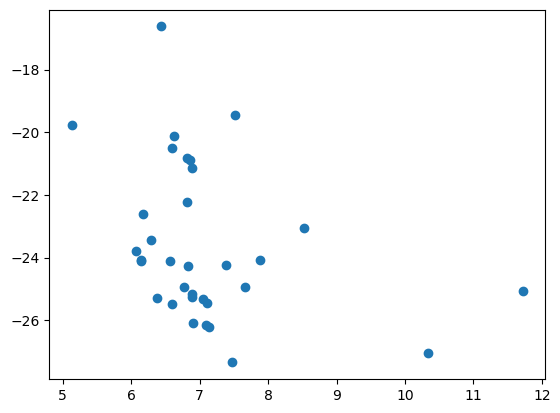

In [139]:
plt.scatter(summary["avg_I_l"], summary["avg_min_nics"])

In [136]:
summary.sort_values(["I_g"])[["I_g", "avg_I_l", "avg_alpha"]]

,I_g,avg_I_l,avg_alpha
structure,,,
SOQYIG,7.774352,6.428087,0.085460
DAFBOC,9.027988,7.521276,0.026096
DOKROM,9.804812,5.130021,0.049577
WURQEF,10.173577,8.525995,0.033634
CEZKEX01,10.275678,6.620380,0.037351
USIVAV,10.300932,6.863069,0.015312
QIHYAJ,10.792110,6.813333,0.002480
FARJIU,10.807632,6.888574,0.022256
ZOXQUA,11.096014,6.819732,0.030986


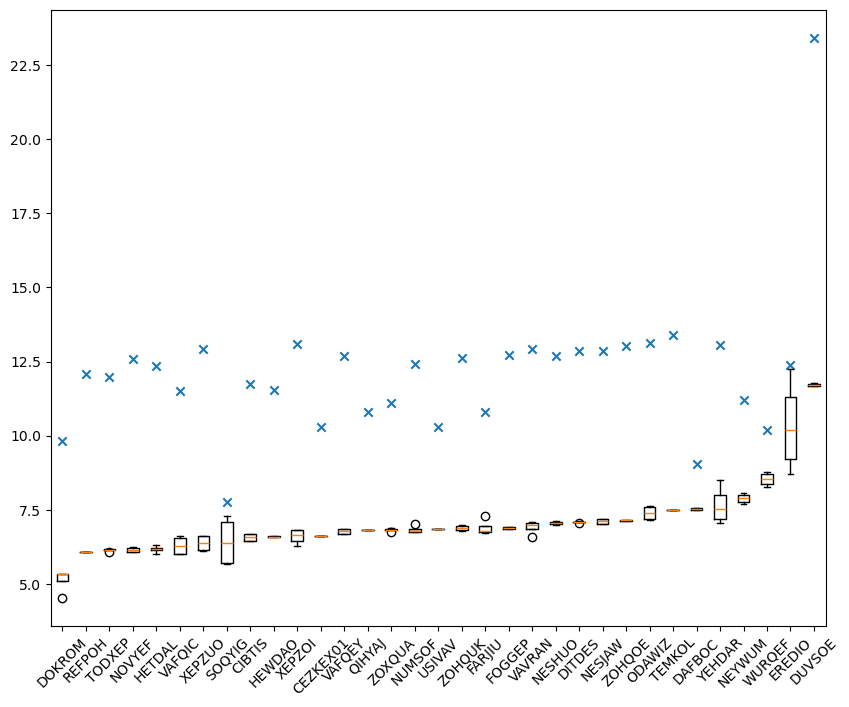

In [138]:
# plt.hist(summary["avg_I_l"], label="local", alpha=0.5)
# plt.hist(summary["I_g"], label="global", alpha=0.5)
# plt.legend()
# plt.figure()
# plt.scatter(summary["avg_I_l"], summary['I_g'])
# xs = plt.xlim()
# plt.plot(xs, xs)
plt.figure(figsize=(10, 8))
summary = summary.sort_values("avg_I_l").iloc[:-1, :]
plt.boxplot(summary[["I_l" + str(i + 1) for i in range(4)]].transpose());
plt.scatter(range(1, len(summary) + 1), summary["I_g"], marker="x");
plt.xticks(range(1, len(summary) + 1), summary.index, rotation=45);